In [1]:
import pickle
import librosa
import numpy as np
import librosa.display
from pathlib import Path
import IPython.display as ipd
import matplotlib.pyplot as plt

In [2]:
NEY_DIR = "dataset/ney/"
GTR_DIR = "dataset/ac_gtr/"

In [3]:
ney_files = sorted([NEY_DIR + f.name for f in Path(NEY_DIR).rglob("*.wav")])
gtr_files = sorted([GTR_DIR + f.name for f in Path(GTR_DIR).rglob("*.wav")])

In [4]:
print(ney_files[0])
print(gtr_files[0])

dataset/ney/00_Ney_C_3.wav
dataset/ac_gtr/00_Gtr_C_3.wav


In [5]:
SR = 48000
MONO = True

In [6]:
ipd.Audio(ney_files[0], rate=SR)

In [7]:
signal, _ = librosa.load(ney_files[0], mono=MONO, sr=SR)
print(signal.shape)

(102000,)


In [8]:
102000/10

10200.0

In [9]:
ipd.Audio(signal[:10200], rate=SR)

In [10]:
FRAME_SIZE = 512
HOP_LENGTH = 256

In [11]:
stft = librosa.stft(signal, n_fft=FRAME_SIZE, hop_length=HOP_LENGTH)[:-1]
print(stft.shape)

(256, 399)


In [12]:
spectrogram = np.abs(stft)
log_spectrogram = librosa.amplitude_to_db(spectrogram)

In [13]:
def plot_spectrogram(Y, sr, hop_length, y_axis="linear"):
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(
        Y,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis)

    plt.colorbar()

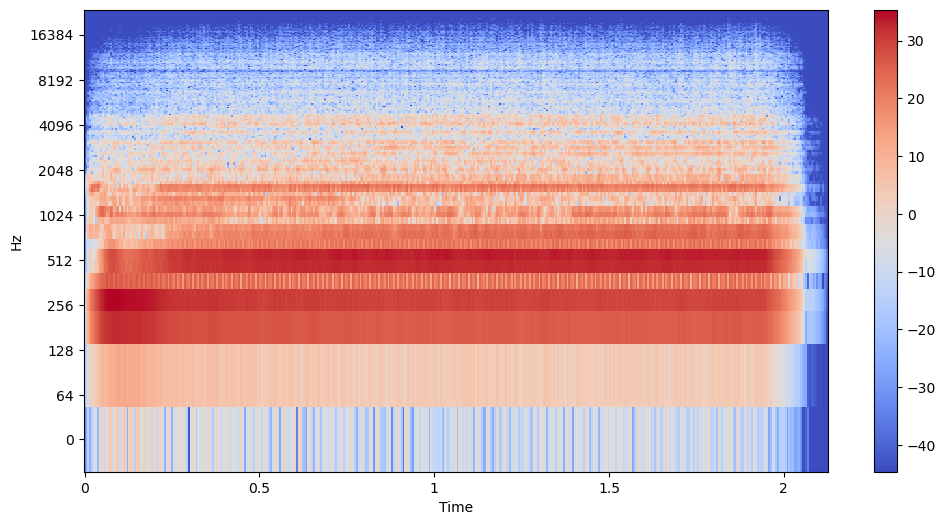

In [14]:
plot_spectrogram(log_spectrogram, SR, HOP_LENGTH, y_axis="log")

(256, 40)


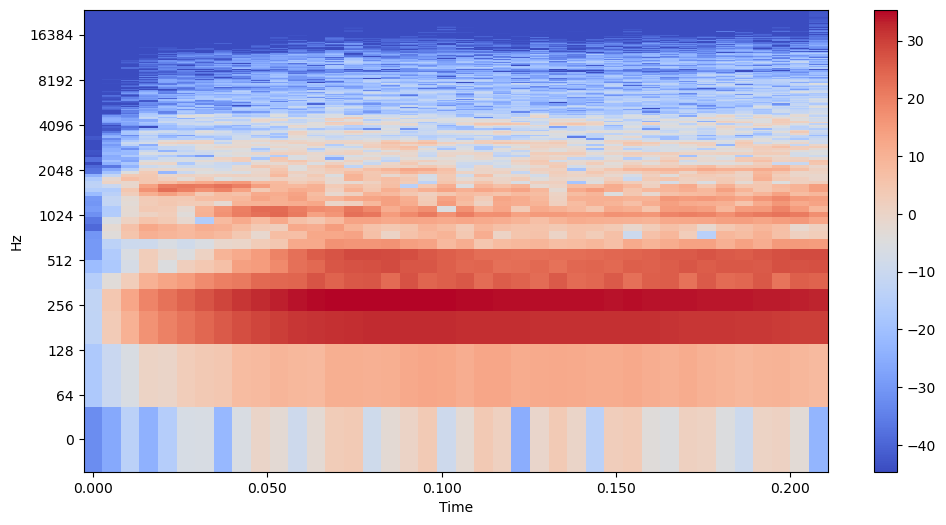

In [24]:
# divide the signal into 10200 samples length parts
signal_subset = signal[:10200]
stft = librosa.stft(signal_subset, n_fft=FRAME_SIZE, hop_length=HOP_LENGTH)[:-1]
print(stft.shape)
spectrogram = np.abs(stft)
log_spectrogram = librosa.amplitude_to_db(spectrogram)
plot_spectrogram(log_spectrogram, SR, HOP_LENGTH, y_axis="log")

In [25]:
len(signal)

102000

In [29]:
WINDOW_LENGTH = 10200
num_windows = int(len(signal) / WINDOW_LENGTH)
for i in range(num_windows):
    signal_window = signal[i*WINDOW_LENGTH: (i+1) * WINDOW_LENGTH]
    print(i, i*WINDOW_LENGTH, (i+1) * WINDOW_LENGTH, len(signal_window))

0 0 10200 10200
1 10200 20400 10200
2 20400 30600 10200
3 30600 40800 10200
4 40800 51000 10200
5 51000 61200 10200
6 61200 71400 10200
7 71400 81600 10200
8 81600 91800 10200
9 91800 102000 10200


In [15]:
NEY_SPECTROGRAM_DIR = "dataset/spectrograms/ney/"
GTR_SPECTROGRAM_DIR = "dataset/spectrograms/ac_gtr/"

In [16]:
Path(ney_files[0]).stem + ".npy"

'00_Ney_C_3.npy'

In [17]:
with open(NEY_SPECTROGRAM_DIR + Path(ney_files[0]).stem + ".npy", "wb") as f:
    pickle.dump(log_spectrogram, f)

In [18]:
loaded_log_spectrogram = np.load(
    NEY_SPECTROGRAM_DIR + Path(ney_files[0]).stem + ".npy", allow_pickle=True)

In [19]:
loaded_log_spectrogram.shape

(256, 399)

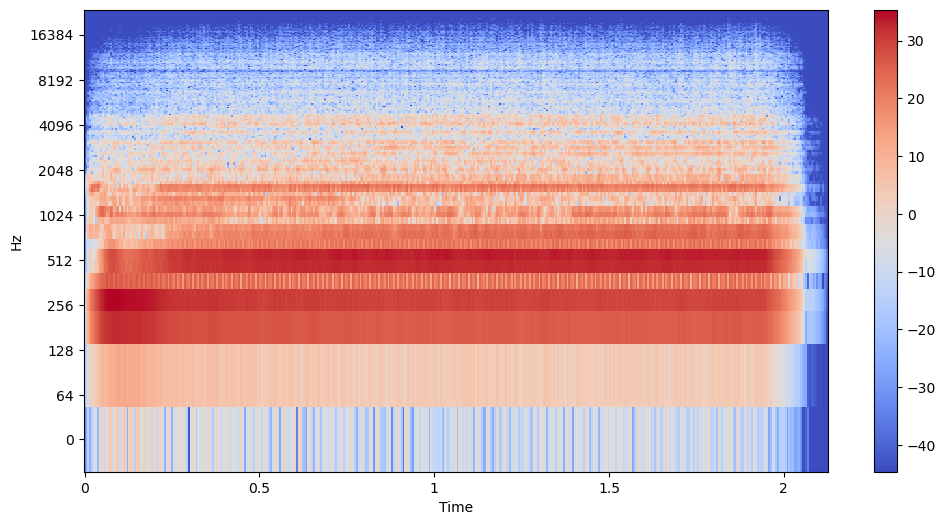

In [20]:
plot_spectrogram(loaded_log_spectrogram, SR, HOP_LENGTH, y_axis="log")

In [35]:
class SignalHandler:
    def __init__(self,
                 ney_audio_dir,
                 gtr_audio_dir,
                 ney_spectrogram_dir,
                 gtr_spectrogram_dir,
                 sr,
                 mono,
                 frame_size,
                 hop_length,
                 window_length):
        self.ney_audio_dir = ney_audio_dir
        self.gtr_audio_dir = gtr_audio_dir
        self.ney_spectrogram_dir = ney_spectrogram_dir
        self.gtr_spectrogram_dir = gtr_spectrogram_dir
        self.sr = sr
        self.mono = mono
        self.frame_size = frame_size
        self.hop_length = hop_length
        self.window_length = window_length
        self.ney_file_paths = []
        self.gtr_file_paths = []
        self.ney_audio_signals = []
        self.gtr_audio_signals = []
        self.ney_spectrograms = []
        self.gtr_spectrograms = []
        self.dataset = {"gtr": [], "ney": []}

    def load_audio_files(self):
        ney_files = sorted(
            [NEY_DIR + f.name for f in Path(NEY_DIR).rglob("*.wav")])
        self.ney_file_paths = ney_files.copy()

        gtr_files = sorted(
            [GTR_DIR + f.name for f in Path(GTR_DIR).rglob("*.wav")])
        self.gtr_file_paths = gtr_files.copy()

        for ney_file in ney_files:
            signal, _ = librosa.load(ney_file, mono=self.mono, sr=self.sr)
            num_windows = int(len(signal) / self.window_length)
            if num_windows != 10:
                raise Exception("Ney signal length mismatch")

            for i in range(num_windows):
                signal_window = signal[i *
                                       self.window_length: (i+1) * self.window_length]
                self.ney_audio_signals.append(signal_window)

        for gtr_file in gtr_files:
            signal, _ = librosa.load(gtr_file, mono=self.mono, sr=self.sr)
            num_windows = int(len(signal) / self.window_length)
            if num_windows != 10:
                raise Exception("Gtr signal length mismatch")

            for i in range(num_windows):
                signal_window = signal[i *
                                       self.window_length: (i+1) * self.window_length]
                self.gtr_audio_signals.append(signal_window)

    def create_spectrograms(self):
        for signal in self.ney_audio_signals:
            stft = librosa.stft(signal,
                                n_fft=self.frame_size,
                                hop_length=self.hop_length)[:-1]
            spectrogram = np.abs(stft)
            log_spectrogram = librosa.amplitude_to_db(spectrogram)
            self.ney_spectrograms.append(log_spectrogram)

        for signal in self.gtr_audio_signals:
            stft = librosa.stft(signal,
                                n_fft=self.frame_size,
                                hop_length=self.hop_length)[:-1]
            spectrogram = np.abs(stft)
            log_spectrogram = librosa.amplitude_to_db(spectrogram)
            self.gtr_spectrograms.append(log_spectrogram)

    def save_spectrograms(self):
        for i, spectrogram in enumerate(self.ney_spectrograms):
            file_name = "ney_" + str(i) + ".npy"
            with open(self.ney_spectrogram_dir + file_name, "wb") as f:
                pickle.dump(spectrogram, f)
                self.dataset["ney"].append(file_name)

        for i, spectrogram in enumerate(self.gtr_spectrograms):
            file_name = "gtr_" + str(i) + ".npy"
            with open(self.gtr_spectrogram_dir + file_name, "wb") as f:
                pickle.dump(spectrogram, f)
                self.dataset["gtr"].append(file_name)

        with open("dataset/dataset.pkl", "wb") as f:
            pickle.dump(self.dataset, f)

In [36]:
NEY_DIR = "dataset/ney/"
GTR_DIR = "dataset/ac_gtr/"
NEY_SPECTROGRAM_DIR = "dataset/spectrograms/ney/"
GTR_SPECTROGRAM_DIR = "dataset/spectrograms/ac_gtr/"
SR = 48000
MONO = True
FRAME_SIZE = 512
HOP_LENGTH = 256
WINDOW_LENGTH = 10200

In [37]:
signal_handler = SignalHandler(NEY_DIR,
                               GTR_DIR,
                               NEY_SPECTROGRAM_DIR,
                               GTR_SPECTROGRAM_DIR,
                               SR,
                               MONO,
                               FRAME_SIZE,
                               HOP_LENGTH,
                               WINDOW_LENGTH)

signal_handler.load_audio_files()
signal_handler.create_spectrograms()
signal_handler.save_spectrograms()

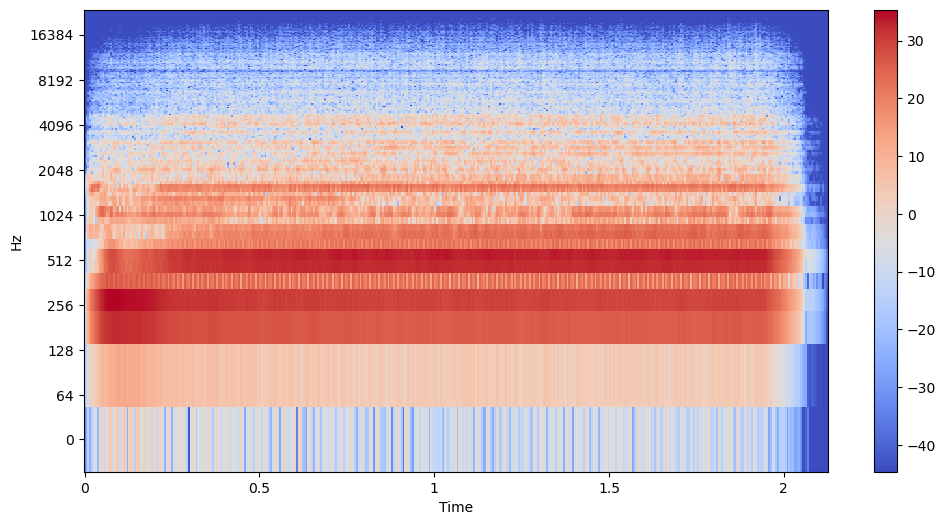

In [67]:
loaded_log_spectrogram = np.load(
    NEY_SPECTROGRAM_DIR + Path(ney_files[0]).stem + ".npy", allow_pickle=True)
plot_spectrogram(loaded_log_spectrogram, SR, HOP_LENGTH, y_axis="log")